# **Univariable Non-Linear Regression Model + L2 Regularization**

In [2]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import random

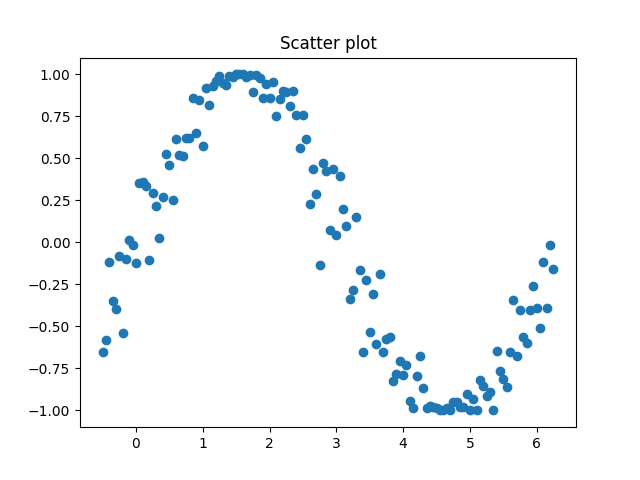

In [106]:
x = np.arange(-0.5, 2*np.pi, 0.05)
y = np.array([np.sin(e + np.random.normal(0, 0.2)) for e in x])

# display(x.shape, y.shape)
# display(x, y)
fig = plt.figure()
plt.title("Scatter plot")
plt.scatter(x, y)

In [107]:
# NORMALIZE DATA for one feature
max_x = np.amax(x)      
min_x = np.amin(x)
    
x = np.array([(e - min_x)/(max_x - min_x) for e in x])

max_y = np.amax(y)
min_y = np.amin(y)
y = np.array([( e - min_y)/(max_y - min_y) for e in y])

# display(x.shape, y.shape)
# display(x, y)

In [108]:
# 70% for train and 30% test
m, = y.shape
idx = np.array(np.arange(m))
include_idx = set(np.random.choice(idx, size = int(0.7*m), replace=False))
mask = np.array([(i in include_idx) for i in range(m)])

trainX = x[mask]
testX = x[~mask]

trainY = y[mask]
testY = y[~mask]

# display(trainX.shape, testX.shape)
# display(trainY.shape, testY.shape)

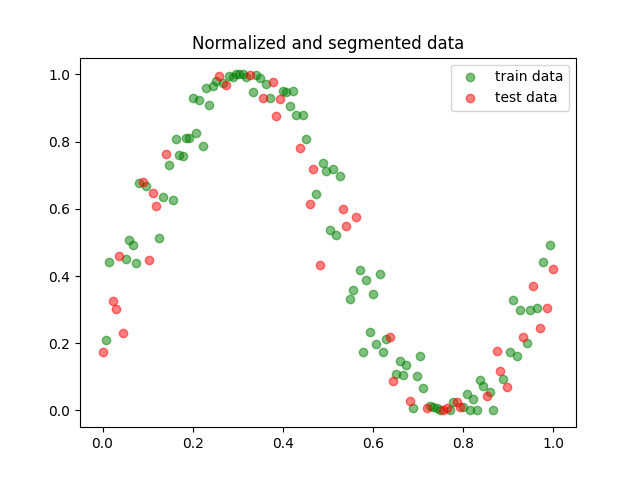

In [109]:
fig = plt.figure()
plt.title("Normalized and segmented data")
plt.scatter(trainX, trainY, color="green", alpha=0.5, label="train data")
plt.scatter(testX, testY, color="red", alpha=0.5, label="test data")
plt.legend()

In [110]:
def h(x, w):
  return np.sum(np.multiply(x, w))

In [111]:
def Error(y, x, w, lambdita):
  m, = y.shape
  e = 0
  for j in range(m):
    sum = (float(y[j] - h(x[j,:], w))**2)/(2.0*m)
    e = e + sum
  n, = w.shape
  l2 = 0
  for i in range(1, n):
    su = ((w[i]**2)/n)*(lambdita)
    l2 = l2 + su
  return e

In [112]:
def derivada(x,y,w, lambdita):
  #implementar las derivadas
  m, = y.shape
  r, c = x.shape

  # first derivative
  derivatives = np.array(
    [ sum([(y[i] - h(x[i,:], w))*-1 for i in range(m)])/(m*1.0) ]
  )
  
  for j in range(1, c):
    der = sum([(y[i] - h(x[i,:], w))*-x[i, j] for i in range(m)])/(m*1.0)
    der = der + (2*w[j])*(lambdita/(m*1.0))
    derivatives = np.append(derivatives, der)
  
  return derivatives

In [113]:
def update(params, alfa, deriv):
  return params - alfa*deriv

In [114]:
arrL = []

def train(x, y, alfa, p, epochs, lambdita):
  w = np.array([np.random.rand() for i in range(p+1)])     # k+1 parametros w0 + w1x1 + ... wkxk
  
  # display(x)
  # display(w)
  i = 0
  for _ in range(epochs):
    L = Error(y, x, w, lambdita)     
    arrL.append(L)
    
    derivatives = derivada(x, y, w, lambdita)
    w = update(w ,alfa, derivatives)     
    
    if _ % 50 == 0:
      print(f"L: {L} ", end="")
    if _ % 100 == 0:
      print()
    
    # time.sleep(2)
  return w

In [115]:
def test(x, y, w, p, lambdita):
   print(f'Error: {Error(y, x, w, lambdita)}')

   # 2D PLOT
   fig = plt.figure()
   plt.title("Error function along training")
   plt.ylabel("L")
   plt.xlabel("epochs")
   plt.plot(np.arange(1,len(arrL)+1), arrL)

   # 2D FUNCTION PLOT
   xAxis = np.linspace(-0.5, 1, 100)
   yAxis = paramArr[0]
   title = str(round(paramArr[0],2))
   for i in range(1, p+1):
      yAxis += paramArr[i]*(xAxis**i)
      title += " + " + str(round(paramArr[i],2)) + f"*x^{i}"
   
   fig = plt.figure()
   plt.title("Univariable Non-Linear Regression")
   plt.scatter(trainX, trainY, color="green", alpha=0.5)
   plt.scatter(testX, testY, color="red", alpha=0.5)
   
   plt.plot(xAxis, yAxis, 'b', label=title)
   plt.legend(loc= 3, prop={'size': 5.5})

In [116]:
# EXTEND ARRAY
p = 9
epochs = 3000
alfa = 0.08568769 # 0.0092795823740238
lambdita = 0.72313468022412435

auxX = []
for feature in trainX:         # feature np.array int
    nRow = []
    for i in range(p+1):
        nRow.append(feature**i)
    auxX.append(nRow)
extendX = np.array(auxX)

In [117]:
arrL = []
paramArr = train(extendX, trainY, alfa , p, epochs, lambdita)
paramArr

L: 0.9344824486143839 
L: 0.06166004735321954 L: 0.03082586957171247 
L: 0.027959968456982835 L: 0.02705981412568893 
L: 0.026453225896784633 L: 0.025982777166404875 
L: 0.025606804435154763 L: 0.02530170254330953 
L: 0.025051123950716285 L: 0.02484314301753735 
L: 0.024668862436957983 L: 0.024521544618428318 
L: 0.024396023408934178 L: 0.024288292073166493 
L: 0.02419520963419057 L: 0.02411428895577958 
L: 0.024043542115424144 L: 0.023981366357778876 
L: 0.02392645906971007 L: 0.023877753712367198 
L: 0.02383437103895076 L: 0.023795581577111313 
L: 0.02376077649994241 L: 0.023729444809211554 
L: 0.02370115531699555 L: 0.02367554231072053 
L: 0.02365229407183775 L: 0.023631143624248 
L: 0.02361186123865743 L: 0.02359424832954381 
L: 0.023578132463613902 L: 0.023563363260409666 
L: 0.023549809012613436 L: 0.02353735388953821 
L: 0.023525895615072873 L: 0.02351534353301357 
L: 0.02350561698972686 L: 0.023496643977543637 
L: 0.023488359992986065 L: 0.02348070707248844 
L: 0.02347363297514

array([ 0.82815192, -0.20834133, -0.49793137, -0.39907719, -0.223656  ,
       -0.04694199,  0.08774301,  0.17295927,  0.2563335 ,  0.30023296])

Error: 0.02340544446792563


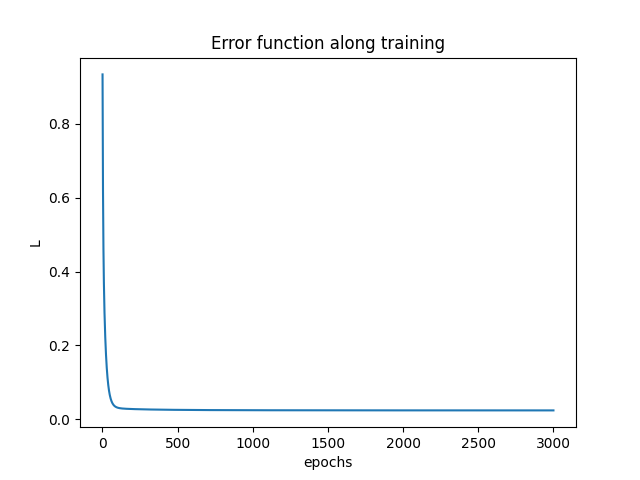

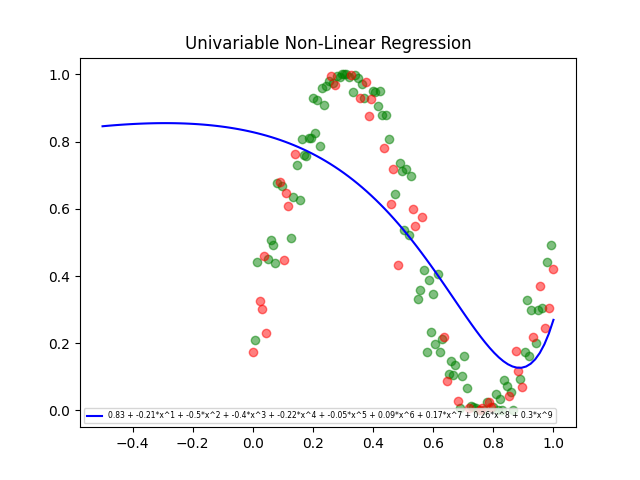

In [118]:
test(extendX, trainY, paramArr, p, lambdita)